In [2]:
import warnings
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import spacy
import time
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras import regularizers
from lime.lime_text import LimeTextExplainer
from sklearn.model_selection import StratifiedKFold

In [3]:
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv(r"C:\Users\sheri\Downloads\Sentiment_Data\Sentiment_Data.csv", encoding="ISO-8859-1")


In [5]:
df = df.head(30000)

# Splitting the data

In [6]:
# Verify the target column and check for unique values before splitting
print("Unique values in original 'Sentiment' column:", df['Sentiment'].unique())

# Split the dataset correctly
X = df.drop('Sentiment', axis=1)
y = df['Sentiment']

# Check the unique values in y (target)
print("Unique values in y (before split):", y.unique())

# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Unique values in original 'Sentiment' column: ['Mild_Pos' 'Strong_Pos' 'Neutral' 'Strong_Neg' 'Mild_Neg']
Unique values in y (before split): ['Mild_Pos' 'Strong_Pos' 'Neutral' 'Strong_Neg' 'Mild_Neg']


# Stop Word and Lemmatization

In [7]:
# Initialize stop words and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Iterate over the rows in the 'Tweet' column of X_train (assuming 'X_train' contains the 'Tweet' column)
for index, row in X_train.iterrows():
    text = str(row['Tweet'])  # Ensure the text is a string

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    
    # Remove mentions (usernames)
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    
    # Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convert text to lowercase
    text = text.lower()
    
    # Tokenization: Split text into words
    words = word_tokenize(text)
    
    # Remove stop words
    words = [word for word in words if word not in stop_words]
    
    # Lemmatization: Convert words to their base form
    words = [lemmatizer.lemmatize(word) for word in words]
    
    # Join the words back into a single string and update the row
    X_train.at[index, 'Tweet'] = ' '.join(words)

# Display the first few rows to see the results
print(X_train[['Tweet']].head())

                                                   Tweet
21753  nazi racist freedom convoy called anti semitis...
251    true freedom convoy emergency lol whole world ...
22941                 thank god long live freedom convoy
618      free tate unjust imprisonment sign petition via
17090  bullshit headline basis reality made people ha...


In [8]:
# Iterate over the rows in the 'Tweet' column of X_train (assuming 'X_train' contains the 'Tweet' column)
for index, row in X_test.iterrows():
    text = str(row['Tweet'])  # Ensure the text is a string

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    
    # Remove mentions (usernames)
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    
    # Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convert text to lowercase
    text = text.lower()
    
    # Tokenization: Split text into words
    words = word_tokenize(text)
    
    # Remove stop words
    words = [word for word in words if word not in stop_words]
    
    # Lemmatization: Convert words to their base form
    words = [lemmatizer.lemmatize(word) for word in words]
    
    # Join the words back into a single string and update the row
    X_test.at[index, 'Tweet'] = ' '.join(words)

# Display the first few rows to see the results
print(X_test[['Tweet']].head())

                                                   Tweet
2308   walk street ottawa freedom convoy interview mu...
22404  part freedom convoy aware politician hill fact...
23397  substack former libs green amp ndp felt party ...
25058  cbc news morning brief freedom convoy already ...
2664   wouldnt compare policing blm protest across u ...


In [9]:
X_train.columns = X_train.columns.str.strip()
X_test.columns = X_test.columns.str.strip()
y_train = y_train.str.strip().str.lower()
y_test = y_test.str.strip().str.lower()

# Emoji Handling

In [10]:
def remove_emojis(text):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"  # Emoticons
        u"\U0001F300-\U0001F5FF"  # Symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # Transport & map symbols
        u"\U0001F700-\U0001F77F"  # Alchemical symbols
        u"\U0001F780-\U0001F7FF"  # Geometric symbols
        u"\U0001F800-\U0001F8FF"  # Supplemental symbols
        u"\U0001F900-\U0001F9FF"  # Additional symbols
        u"\U0001FA00-\U0001FA6F"  # Symbols for emoji components
        u"\U0001FA70-\U0001FAFF"  # Additional symbols
        u"\U00002702-\U000027B0"  # Dingbats
        "]+", flags=re.UNICODE)
    
    return emoji_pattern.sub(r'', text)

# Apply function
X_train['Tweet'] = X_train['Tweet'].apply(remove_emojis)
X_test['Tweet'] = X_test['Tweet'].apply(remove_emojis)

# Slang Handling

In [11]:
slang_dict = {
    "brb": "be right back",
    "btw": "by the way",
    "dm": "direct message",
    "fyi": "for your information",
    "idk": "I do not know",
    "imo": "in my opinion",
    "irl": "in real life",
    "jk": "just kidding",
    "lmao": "laughing my ass off",
    "lol": "laugh out loud",
    "nvm": "never mind",
    "omg": "oh my god",
    "rofl": "rolling on the floor laughing",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "ttyl": "talk to you later",
    "wth": "what the heck",
    "wyd": "what are you doing",
    "wym": "what you mean",
    "yeet": "throw something with force",
    "xoxo": "hugs and kisses",
    "hmu": "hit me up",
    "sus": "suspicious",
    "cap": "lie",
    "no cap": "not lying",
    "rn": "right now",
    "clout": "influence or fame",
    "fomo": "fear of missing out",
    "finna": "fixing to, about to",
    "lowkey": "quietly or secretly",
    "highkey": "not secretly, obviously",
    "lit": "amazing, cool",
    "mood": "relatable feeling",
    "vibe": "atmosphere or feeling",
    "stan": "overly obsessed fan",
    "savage": "bold or ruthless",
    "woke": "socially aware",
    "ghosting": "suddenly ignoring someone",
    "salty": "bitter or upset",
    "simp": "overly attentive to someone",
    "thirsty": "desperate for attention",
    "flex": "showing off",
    "bop": "good song",
    "banger": "great song or event",
    "drip": "stylish or fashionable",
    "gucci": "good, okay",
    "dope": "cool",
    "bet": "okay, agreed",
    "tea": "gossip or drama",
    "big yikes": "very embarrassing",
    "extra": "over the top",
    "shook": "shocked or surprised",
    "goat": "greatest of all time",
    "dead": "laughing hard",
    "hundo p": "100 percent",
    "af": "as f***",
    "wp": "well played",
    "gg": "good game",
    "ggwp": "good game, well played",
    "irl": "in real life",
    "afk": "away from keyboard",
    "rekt": "totally destroyed",
    "lag": "slow internet response",
    "op": "overpowered",
    "nerf": "make weaker",
    "buff": "make stronger",
    "tryhard": "someone who plays too seriously",
    "ez": "easy win",
    "grind": "working hard for progress",
    "pog": "amazing or exciting",
    "poggers": "even more amazing",
    "wtf": "what the f***",
    "idc": "I do not care",
    "idgaf": "I do not give a f***",
    "ftw": "for the win",
    "np": "no problem",
    "sksksk": "expression of excitement or laughter",
    "and i oop": "reaction to something surprising",
    "basic": "mainstream, unoriginal",
    "bff": "best friends forever",
    "boomer": "old person with outdated opinions",
    "clapback": "a clever comeback",
    "karens": "entitled or rude person",
    "boi": "boy",
    "dm me": "direct message me",
    "irl": "in real life",
    "rekt": "totally destroyed",
    "gf": "girlfriend",
    "bf": "boyfriend",
    "wyd": "what you doing",
    "wym": "what you mean",
    "fr": "for real",
    "on god": "I swear",
    "g2g": "got to go",
    "bih": "variation of b****",
    "luv": "love",
    "tmw": "tomorrow",
    "frfr": "for real, for real",
    "idc": "I do not care",
    "lmk": "let me know",
    "tgif": "thank god it’s Friday",
    "nsfw": "not safe for work",
    "sfw": "safe for work",
    "doe": "though",
    "ion": "I don’t",
    "y’all": "you all",
    "bro": "brother",
    "fam": "family",
    "sry": "sorry",
    "wtf": "what the f***",
    "wbu": "what about you",
    "roflmao": "rolling on the floor laughing my ass off",
    "stfu": "shut the f*** up",
    "gn": "good night",
    "gm": "good morning",
    "ily": "I love you",
    "ily2": "I love you too",
    "nfs": "not for sale",
    "bih": "variation of b****",
    "gr8": "great",
    "thx": "thanks",
    "omw": "on my way",
    "ppl": "people",
    "tl;dr": "too long; didn’t read",
    "fml": "f*** my life",
    "hand": "have a nice day",
    "jsyk": "just so you know",
    "ptfo": "passed the f*** out",
    "rn": "right now",
    "ikr": "I know, right?",
    "gf": "girlfriend",
    "bf": "boyfriend",
    "gg": "good game",
    "bg": "bad game",
    "ffs": "for f***’s sake",
    "ggno": "good game, no offense",
    "l8r": "later",
    "np": "no problem",
    "w/e": "whatever",
    "u2": "you too",
    "idc": "I don’t care",
    "wth": "what the heck",
    "yolo": "you only live once",
    "atm": "at the moment",
    "jk": "just kidding",
    "g2g": "got to go",
}


In [12]:
def replace_slang(text):
    words = text.split()
    new_text = " ".join([slang_dict[word.lower()] if word.lower() in slang_dict else word for word in words])
    return new_text

# Apply to tweets
X_train['Tweet'] = X_train['Tweet'].apply(replace_slang)
X_test['Tweet'] = X_test['Tweet'].apply(replace_slang)

# Abbreviation Handling

In [13]:
abbreviation_dict = {
    "u": "you",
    "r": "are",
    "y": "why",
    "abt": "about",
    "asap": "as soon as possible",
    "b4": "before",
    "b/c": "because",
    "cuz": "because",
    "btw": "by the way",
    "dm": "direct message",
    "esp": "especially",
    "fav": "favorite",
    "fwd": "forward",
    "govt": "government",
    "gr8": "great",
    "idk": "I do not know",
    "ikr": "I know, right?",
    "imo": "in my opinion",
    "irl": "in real life",
    "jk": "just kidding",
    "lmk": "let me know",
    "msg": "message",
    "nvm": "never mind",
    "pls": "please",
    "plz": "please",
    "ppl": "people",
    "thx": "thanks",
    "ty": "thank you",
    "ttyl": "talk to you later",
    "w/o": "without",
    "w/": "with",
    "wth": "what the heck",
    "ya": "you",
    "y'all": "you all",
    "yolo": "you only live once",
    "atm": "at the moment",
    "bff": "best friends forever",
    "brb": "be right back",
    "cu": "see you",
    "fyi": "for your information",
    "gg": "good game",
    "g2g": "got to go",
    "hmu": "hit me up",
    "icymi": "in case you missed it",
    "idc": "I do not care",
    "lmao": "laughing my ass off",
    "lol": "laugh out loud",
    "nsfw": "not safe for work",
    "omg": "oh my god",
    "rn": "right now",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "tl;dr": "too long; didn’t read",
    "ttfn": "ta-ta for now",
    "tysm": "thank you so much",
    "wyd": "what are you doing",
    "wym": "what you mean",
    "xoxo": "hugs and kisses",
    "bday": "birthday",
    "gf": "girlfriend",
    "bf": "boyfriend",
    "np": "no problem",
    "ftw": "for the win",
    "ily": "I love you",
    "ilu": "I love you",
    "jk": "just kidding",
    "ggwp": "good game, well played",
    "pov": "point of view",
    "fomo": "fear of missing out",
    "fr": "for real",
    "bruh": "brother",
    "cap": "lie",
    "no cap": "not lying",
    "sus": "suspicious",
    "bt": "but",
    "tho": "though",
    "gg": "good game",
    "op": "overpowered",
    "afk": "away from keyboard",
    "irl": "in real life",
    "wp": "well played",
    "jk": "just kidding",
    "ikr": "I know, right?",
}
def replace_abbreviations(text):
    words = text.split()
    new_text = " ".join([abbreviation_dict[word.lower()] if word.lower() in abbreviation_dict else word for word in words])
    return new_text

# Apply to tweets
X_train['Tweet'] = X_train['Tweet'].apply(replace_abbreviations)
X_test['Tweet'] = X_test['Tweet'].apply(replace_abbreviations)

# Idiom Handling

In [14]:
idiom_dict = {
    "kick the bucket": "death",
    "break the ice": "start a conversation",
    "spill the beans": "reveal a secret",
    "hit the nail on the head": "correctly identify",
    "under the weather": "feeling ill",
    "piece of cake": "easy",
    "raining cats and dogs": "heavy rain",
    "burning the midnight oil": "working late",
    "bite the bullet": "accept something difficult",
    "caught between a rock and a hard place": "faced with two difficult choices",
    "cost an arm and a leg": "very expensive",
    "cry over spilled milk": "worry about something that can't be undone",
    "drive someone up the wall": "annoy someone intensely",
    "elephant in the room": "an obvious problem that is being ignored",
    "get cold feet": "to be nervous or have second thoughts",
    "hit the sack": "go to bed",
    "in hot water": "in trouble",
    "let the cat out of the bag": "reveal a secret accidentally",
    "make a mountain out of a molehill": "exaggerate a small issue",
    "miss the boat": "miss an opportunity",
    "once in a blue moon": "very rarely",
    "out of the blue": "unexpectedly",
    "raining cats and dogs": "heavy rain",
    "step up to the plate": "take responsibility",
    "the ball is in your court": "it’s your decision or responsibility",
    "the best of both worlds": "a situation where you can enjoy two different opportunities",
    "the early bird catches the worm": "the person who arrives first has the advantage",
    "through thick and thin": "through difficult times and easy times",
    "turn a blind eye": "pretend not to notice something",
    "under someone's thumb": "controlled or dominated by someone",
    "when pigs fly": "something that will never happen",
    "you can't judge a book by its cover": "don't judge someone by appearance",
    "your guess is as good as mine": "I don't know either",
    "a blessing in disguise": "something that seems bad but turns out good",
    "a dime a dozen": "very common and easy to find",
    "a taste of your own medicine": "getting treated the way you've been treating others",
    "barking up the wrong tree": "making a false assumption or pursuing a wrong course",
    "beat around the bush": "avoid talking about something directly",
    "by the skin of your teeth": "just barely",
    "don't count your chickens before they hatch": "don't assume something will happen before it does",
    "drop the ball": "make a mistake or fail",
    "get your act together": "organize yourself and your work",
    "have a heart of gold": "to be kind and generous",
    "hit the ground running": "start something and immediately become successful",
    "in a nutshell": "in summary",
    "kill two birds with one stone": "accomplish two tasks with one action",
    "let sleeping dogs lie": "avoid interfering in a situation that is better left alone",
    "miss the mark": "fail to achieve the intended result",
    "on the ball": "alert and efficient",
    "put all your eggs in one basket": "rely on a single opportunity",
    "shoot the breeze": "chat casually",
    "the straw that broke the camel's back": "a small problem that causes a major issue",
    "think outside the box": "think creatively or unconventionally",
    "to add insult to injury": "make a bad situation worse",
    "to be in the same boat": "to be in the same situation",
    "to beat a dead horse": "to continue discussing a point that has already been settled",
    "to bury the hatchet": "to make peace",
    "to burn bridges": "to destroy one's path or connections"
}
def replace_idioms(text):
    for idiom, meaning in idiom_dict.items():
        if idiom in text:
            text = text.replace(idiom, meaning)
    return text

# Apply idiom replacement
X_train['Tweet'] = X_train['Tweet'].apply(replace_idioms)
X_test['Tweet'] = X_test['Tweet'].apply(replace_idioms)


# Negation Handling

In [15]:
negation_words = [
    'not', 'no', 'never', 'nothing', 'nobody', 'none', 'neither', 'nowhere',
    'doesn\'t', 'isn\'t', 'wasn\'t', 'aren\'t', 'can\'t', 'won\'t', 'don\'t',
    'hadn\'t', 'haven\'t', 'shouldn\'t', 'mightn\'t', 'mustn\'t', 'couldn\'t',
    'wouldn\'t', 'won\'t', 'neither', 'nor', 'barely', 'seldom', 'hardly', 'rarely',
    'nope', 'nah', 'none', 'not any', 'not at all', 'don\'t', 'didn\'t', 'can\'t',
    'won\'t', 'wasn\'t', 'doesn\'t', 'isn\'t', 'ain\'t', 'without', 'nothing at all',
    'no longer', 'not yet', 'nothing but', 'not even', 'not quite', 'in no way',
    'under no circumstances', 'by no means', 'out of the question', 'hardly ever',
    'in no case', 'not a bit', 'not any longer', 'not a single', 'never again',
    'not really', 'not so much', 'no way', 'cannot', 'not enough', 'no choice',
    'not so', 'none of', 'don’t', 'could never', 'should never', 'must not',
    'not particularly', 'not the case', 'not at all', 'not yet', 'no such', 'not true',
    'not possible', 'not likely', 'not exactly', 'not yet', 'no more', 'not at this point',
    'no chance', 'no good', 'no longer', 'no matter', 'no doubt', 'nothing ever', 'never more',
    'not this time', 'no one', 'no one ever', 'nothing ever again', 'no way around it',
    'no one will', 'no idea', 'not to be', 'out of the question', 'nevermore', 'not my fault',
    'cannot stand', 'would never', 'never ever', 'in no circumstances', 'not that way',
    'not likely', 'not valid', 'unacceptable', 'unbelievable', 'impossible'
]


In [16]:
# Load the spaCy model
nlp = spacy.load("en_core_web_sm")

# Function to detect negation in text
def detect_negation(text):
    # Process the text using spaCy
    doc = nlp(text)
    
    # Flag to track if negation is found
    negation_detected = False
    
    # Check for negation words or dependency
    for token in doc:
        if token.text.lower() in negation_words or token.dep_ == 'neg':
            negation_detected = True
            break
    
    return negation_detected

# Apply negation detection to each individual sentence in X_train and X_test
train_negation = X_train['Tweet'].apply(lambda text: detect_negation(str(text)))  
test_negation = X_test['Tweet'].apply(lambda text: detect_negation(str(text)))  

# Add the negation detection results as a new feature/column in X_train and X_test
X_train['negation_detected'] = train_negation
X_test['negation_detected'] = test_negation

# Display the resulting DataFrames
print("Updated X_train with negation feature:")
print(X_train.head())  # Display first few rows

print("\nUpdated X_test with negation feature:")
print(X_test.head())  # Display first few rows


Updated X_train with negation feature:
                                                   Tweet  negation_detected
21753  nazi racist freedom convoy called anti semitis...              False
251    true freedom convoy emergency laugh out loud w...              False
22941                 thank god long live freedom convoy              False
618      free tate unjust imprisonment sign petition via              False
17090  bullshit headline basis reality made people ha...               True

Updated X_test with negation feature:
                                                   Tweet  negation_detected
2308   walk street ottawa freedom convoy interview mu...              False
22404  part freedom convoy aware politician hill fact...              False
23397  substack former libs green amp ndp felt party ...               True
25058  cbc news morning brief freedom convoy already ...              False
2664   wouldnt compare policing blm protest across yo...               True


In [17]:
# Define the updated sentiment mapping
sentiment_mapping = {
    'mild_pos': 'positive',  
    'mild_neg': 'negative',  
    'strong_pos': 'positive',  
    'strong_neg': 'negative',  
    'neutral': 'neutral'  
}


y_train = y_train.map(sentiment_mapping)


y_train = y_train.fillna('unknown')

# Check the unique values in y_train after mapping
print("Unique values in y_train after mapping:", y_train.unique())


Unique values in y_train after mapping: ['positive' 'negative' 'neutral']


In [18]:
y_test = y_test.map(sentiment_mapping)

# Fill any NaN values with 'unknown' (though this shouldn't be necessary now)
y_test = y_test.fillna('unknown')

# Check the unique values in y_train after mapping
print("Unique values in y_train after mapping:", y_train.unique())

Unique values in y_train after mapping: ['positive' 'negative' 'neutral']


In [19]:
# Encoding the sentiments directly in the y_train Series
y_train_encoded = y_train.map({'positive': 1, 'neutral': 0, 'negative': 2})
y_test_encoded = y_test.map({'positive': 1, 'neutral': 0, 'negative': 2})
# Check the unique values in the encoded column
print(y_train_encoded.unique())
print(y_test_encoded.unique())

[1 2 0]
[1 2 0]


In [20]:
X_train = X_train['Tweet']
X_test = X_test['Tweet']

# Tokenization

In [21]:
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>') 
tokenizer.fit_on_texts(X_train)

In [22]:
# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)



In [23]:

maxlen = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen)
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen)

# Model Configuration

Epoch 1/5
375/375 [==============================] - 51s 123ms/step - loss: 0.6673 - accuracy: 0.7471 - val_loss: 0.5530 - val_accuracy: 0.7940
Epoch 2/5
375/375 [==============================] - 44s 117ms/step - loss: 0.4519 - accuracy: 0.8365 - val_loss: 0.5565 - val_accuracy: 0.8002
Epoch 3/5
375/375 [==============================] - 44s 118ms/step - loss: 0.3602 - accuracy: 0.8751 - val_loss: 0.5723 - val_accuracy: 0.8000
Epoch 4/5
375/375 [==============================] - 44s 117ms/step - loss: 0.2992 - accuracy: 0.8975 - val_loss: 0.6168 - val_accuracy: 0.7985
Epoch 5/5
375/375 [==============================] - 43s 114ms/step - loss: 0.2903 - accuracy: 0.8988 - val_loss: 0.6927 - val_accuracy: 0.7810
Train Time = 225.61112928390503 seconds
188/188 [==============================] - 5s 20ms/step
Test Time = 4.747174263000488 seconds


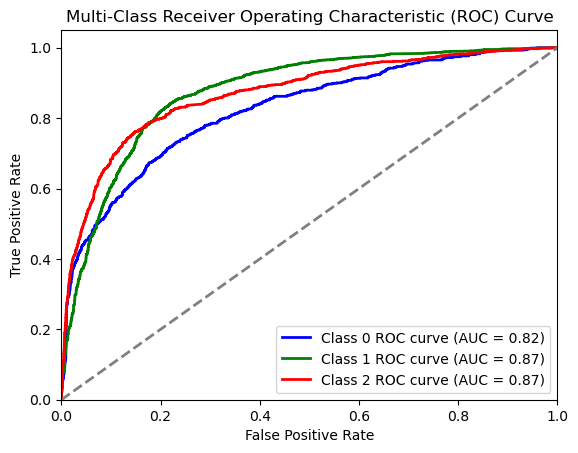

AUC for Class 0: 0.8231
AUC for Class 1: 0.8748
AUC for Class 2: 0.8695
Training Data Shape: (24000, 100)
Training Labels Shape: (24000,)
Confusion Matrix (Test):
[[ 438  321  103]
 [ 229 3655  194]
 [ 172  295  593]]
Classification Report (Test):
               precision    recall  f1-score   support

     Class 0       0.52      0.51      0.51       862
     Class 1       0.86      0.90      0.88      4078
     Class 2       0.67      0.56      0.61      1060

    accuracy                           0.78      6000
   macro avg       0.68      0.65      0.67      6000
weighted avg       0.77      0.78      0.78      6000

Test Accuracy = 0.7810
750/750 [==============================] - 15s 21ms/step
Confusion Matrix (Train):
[[ 3034   376   136]
 [  227 16060   142]
 [  150   359  3516]]
Classification Report (Train):
               precision    recall  f1-score   support

     Class 0       0.89      0.86      0.87      3546
     Class 1       0.96      0.98      0.97     16429
     

In [24]:
# Model configuration
vocab_size = 10000  
embedding_dim = 100 
max_length = 100 

# Define the model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
model.add(Bidirectional(LSTM(units=64, return_sequences=False)))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training the model
start_train_time = time.time()
history = model.fit(X_train_pad, y_train_encoded, epochs=5, batch_size=64, validation_data=(X_test_pad, y_test_encoded))
end_train_time = time.time()
train_time = end_train_time - start_train_time
print(f"Train Time = {train_time} seconds")

# Predicting with the trained model
start_test_time = time.time()
y_pred_prob = model.predict(X_test_pad) 
end_test_time = time.time()
test_time = end_test_time - start_test_time
print(f"Test Time = {test_time} seconds")

# Convert the labels to binary format (one-vs-rest) for multi-class ROC curve
y_test_binary = label_binarize(y_test_encoded, classes=[0, 1, 2])

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):  # For each class (0, 1, 2)
    fpr[i], tpr[i], _ = roc_curve(y_test_binary[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure()
colors = ['blue', 'green', 'red']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} ROC curve (AUC = {roc_auc[i]:.2f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Labels and title
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# AUC Scores
for i in range(3):
    print(f"AUC for Class {i}: {roc_auc[i]:.4f}")

# Training data check
print(f"Training Data Shape: {X_train_pad.shape}")
print(f"Training Labels Shape: {y_train_encoded.shape}")

# Confusion Matrix and Classification Report for Test Data
y_pred_test = np.argmax(y_pred_prob, axis=1)
cm_test = confusion_matrix(y_test_encoded, y_pred_test)
print("Confusion Matrix (Test):")
print(cm_test)

report_test = classification_report(y_test_encoded, y_pred_test, target_names=["Class 0", "Class 1", "Class 2"])
print("Classification Report (Test):\n", report_test)

# Accuracy computation for Test
test_accuracy = accuracy_score(y_test_encoded, y_pred_test)
print(f"Test Accuracy = {test_accuracy:.4f}")

# Predicting with the model on Train Data
y_pred_train_prob = model.predict(X_train_pad)  # Get predicted probabilities on training data

# Confusion Matrix and Classification Report for Train Data
y_pred_train = np.argmax(y_pred_train_prob, axis=1)
cm_train = confusion_matrix(y_train_encoded, y_pred_train)
print("Confusion Matrix (Train):")
print(cm_train)

report_train = classification_report(y_train_encoded, y_pred_train, target_names=["Class 0", "Class 1", "Class 2"])
print("Classification Report (Train):\n", report_train)

# Accuracy computation for Train
train_accuracy = accuracy_score(y_train_encoded, y_pred_train)
print(f"Train Accuracy = {train_accuracy:.4f}")

# Training and Test time
print(f"Training Time: {train_time:.4f} seconds")


# Tuning Iteration 1

Epoch 1/5
750/750 [==============================] - 104s 134ms/step - loss: 0.8293 - accuracy: 0.7406 - val_loss: 0.5934 - val_accuracy: 0.7800 - lr: 0.0010
Epoch 2/5
750/750 [==============================] - 107s 143ms/step - loss: 0.4951 - accuracy: 0.8266 - val_loss: 0.5503 - val_accuracy: 0.8018 - lr: 9.0000e-04
Epoch 3/5
750/750 [==============================] - 116s 154ms/step - loss: 0.4538 - accuracy: 0.8465 - val_loss: 0.5831 - val_accuracy: 0.7977 - lr: 8.1000e-04
Epoch 4/5
750/750 [==============================] - 104s 139ms/step - loss: 0.3626 - accuracy: 0.8802 - val_loss: 0.5935 - val_accuracy: 0.7923 - lr: 7.2900e-04
Epoch 5/5
750/750 [==============================] - 109s 146ms/step - loss: 0.3191 - accuracy: 0.8959 - val_loss: 0.6495 - val_accuracy: 0.7830 - lr: 6.5610e-04
Train Time = 541.959703207016 seconds
188/188 [==============================] - 8s 38ms/step


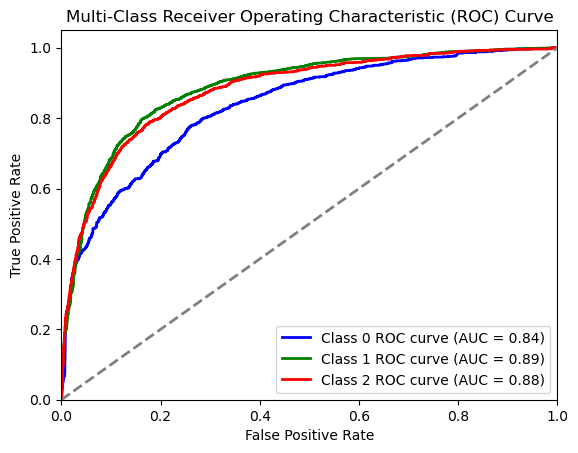

AUC for Class 0: 0.8357
AUC for Class 1: 0.8862
AUC for Class 2: 0.8786
Training Data Shape: (24000, 100)
Training Labels Shape: (24000,)
Confusion Matrix:
[[ 393  323  146]
 [ 152 3647  279]
 [ 144  258  658]]
Classification Report:
               precision    recall  f1-score   support

     Class 0       0.57      0.46      0.51       862
     Class 1       0.86      0.89      0.88      4078
     Class 2       0.61      0.62      0.61      1060

    accuracy                           0.78      6000
   macro avg       0.68      0.66      0.67      6000
weighted avg       0.78      0.78      0.78      6000

Test Accuracy = 0.7830


In [25]:
# Hyperparameters
vocab_size = 10000  
embedding_dim = 100  
max_length = 100 

# Learning rate scheduler function
def lr_schedule(epoch):
    lr = 1e-3 * 0.9 ** epoch 
    return lr

# Define model function
def create_model(units=128, dropout_rate=0.3, embedding_matrix=None):
    model = Sequential()
    
    # If you have pre-trained embeddings, use them
    if embedding_matrix is not None:
        model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                            input_length=max_length, weights=[embedding_matrix], trainable=False))
    else:
        model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
    
    # Bidirectional LSTM
    model.add(Bidirectional(LSTM(units=units, return_sequences=False, 
                                  kernel_regularizer=regularizers.l2(0.01))))
    model.add(Dropout(dropout_rate))
    model.add(Dense(3, activation='softmax'))

    # Compile the model
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Model training with tuning hyperparameters (LSTM units, dropout rate, etc.)
start_time = time.time()
model = create_model(units=128, dropout_rate=0.3)

# Learning rate scheduler callback
lr_scheduler = LearningRateScheduler(lr_schedule)

history = model.fit(X_train_pad, y_train_encoded, epochs=5, batch_size=32, 
                    validation_data=(X_test_pad, y_test_encoded), callbacks=[lr_scheduler])

end_time = time.time()
train_time = end_time - start_time
print(f"Train Time = {train_time} seconds")

# Predicting with the trained model
y_pred_prob = model.predict(X_test_pad)

# Convert the labels to binary format (one-vs-rest) for multi-class ROC curve
y_test_binary = label_binarize(y_test_encoded, classes=[0, 1, 2])

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):  # For each class (0, 1, 2)
    fpr[i], tpr[i], _ = roc_curve(y_test_binary[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure()
colors = ['blue', 'green', 'red']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} ROC curve (AUC = {roc_auc[i]:.2f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Labels and title
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# AUC Scores
for i in range(3):
    print(f"AUC for Class {i}: {roc_auc[i]:.4f}")

# Training data check
print(f"Training Data Shape: {X_train_pad.shape}")
print(f"Training Labels Shape: {y_train_encoded.shape}")

# Confusion Matrix
y_pred = np.argmax(y_pred_prob, axis=1)
cm = confusion_matrix(y_test_encoded, y_pred)
print("Confusion Matrix:")
print(cm)

# F1 Score for Positive and Negative Classes
report = classification_report(y_test_encoded, y_pred, target_names=["Class 0", "Class 1", "Class 2"])
print("Classification Report:\n", report)

# Accuracy computation
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Test Accuracy = {accuracy:.4f}")


# Iteration 2

Epoch 1/10
750/750 [==============================] - ETA: 0s - loss: 0.9062 - accuracy: 0.7189
Epoch 1: val_loss improved from inf to 0.66536, saving model to best_model.h5
750/750 [==============================] - 2002s 3s/step - loss: 0.9062 - accuracy: 0.7189 - val_loss: 0.6654 - val_accuracy: 0.7577 - lr: 0.0010
Epoch 2/10
750/750 [==============================] - ETA: 0s - loss: 0.5914 - accuracy: 0.7930
Epoch 2: val_loss improved from 0.66536 to 0.60930, saving model to best_model.h5
750/750 [==============================] - 103s 137ms/step - loss: 0.5914 - accuracy: 0.7930 - val_loss: 0.6093 - val_accuracy: 0.7835 - lr: 9.0000e-04
Epoch 3/10
750/750 [==============================] - ETA: 0s - loss: 0.5065 - accuracy: 0.8315
Epoch 3: val_loss did not improve from 0.60930
750/750 [==============================] - 103s 137ms/step - loss: 0.5065 - accuracy: 0.8315 - val_loss: 0.6111 - val_accuracy: 0.7882 - lr: 8.1000e-04
Epoch 4/10
750/750 [==============================] - E

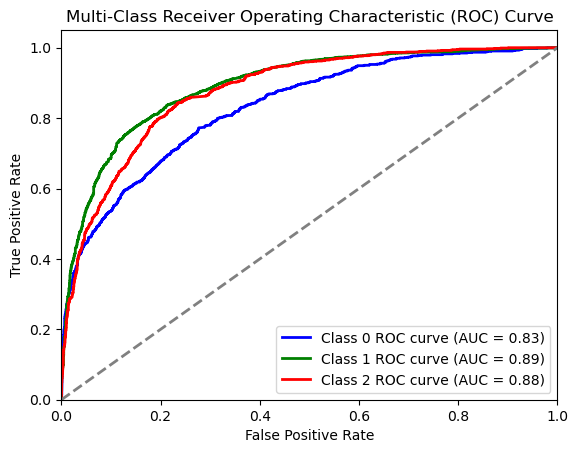

AUC for Class 0: 0.8307
AUC for Class 1: 0.8916
AUC for Class 2: 0.8773
Training Data Shape: (24000, 100)
Training Labels Shape: (24000,)
Confusion Matrix:
[[ 347  358  157]
 [  66 3782  230]
 [ 114  374  572]]
Classification Report:
               precision    recall  f1-score   support

     Class 0       0.66      0.40      0.50       862
     Class 1       0.84      0.93      0.88      4078
     Class 2       0.60      0.54      0.57      1060

    accuracy                           0.78      6000
   macro avg       0.70      0.62      0.65      6000
weighted avg       0.77      0.78      0.77      6000

Test Accuracy = 0.7835


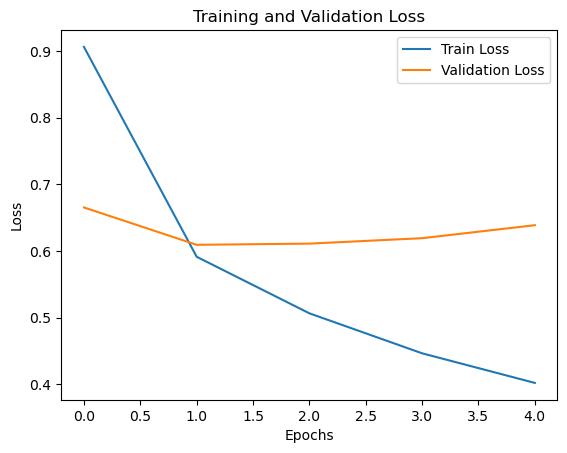

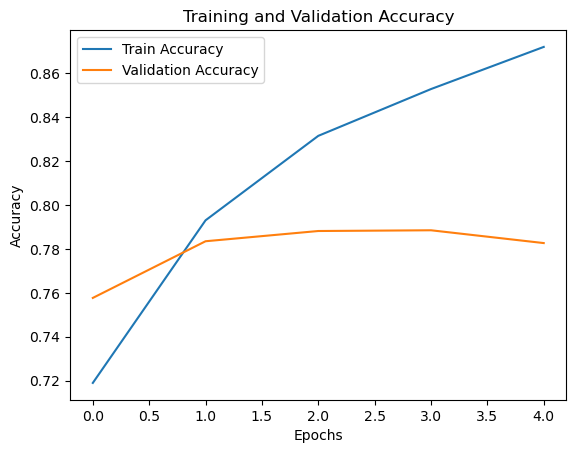

In [26]:


# Hyperparameters for the 2nd iteration
vocab_size = 10000  
embedding_dim = 100  
max_length = 100  

# Learning rate scheduler function
def lr_schedule(epoch):
    lr = 1e-3 * 0.9 ** epoch 
    return lr

# Define model function with added regularization
def create_model(units=128, dropout_rate=0.5, embedding_matrix=None):
    model = Sequential()
    
    # If you have pre-trained embeddings, use them
    if embedding_matrix is not None:
        model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                            input_length=max_length, weights=[embedding_matrix], trainable=False))
    else:
        model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
    
    # Bidirectional LSTM with L2 regularization
    model.add(Bidirectional(LSTM(units=units, return_sequences=False, 
                                  kernel_regularizer=regularizers.l2(0.01))))  
    model.add(Dropout(dropout_rate))  # Dropout to prevent overfitting
    model.add(Dense(3, activation='softmax', kernel_regularizer=regularizers.l2(0.01)))

    # Compile the model
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Model training with tuning hyperparameters (LSTM units, dropout rate, etc.)
start_time = time.time()

# Early stopping callback to halt training when validation loss stops improving
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Model Checkpoint to save the best model during training
model_checkpoint = ModelCheckpoint("best_model.h5", monitor="val_loss", save_best_only=True, verbose=1)

# Learning rate scheduler callback
lr_scheduler = LearningRateScheduler(lr_schedule)

# Create and train the model
model = create_model(units=128, dropout_rate=0.5)

history = model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=32, 
                    validation_data=(X_test_pad, y_test_encoded),
                    callbacks=[early_stopping, model_checkpoint, lr_scheduler])

end_time = time.time()
train_time = end_time - start_time
print(f"Train Time = {train_time} seconds")

# Predicting with the trained model
y_pred_prob = model.predict(X_test_pad)  # Get predicted probabilities

# Convert the labels to binary format (one-vs-rest) for multi-class ROC curve
y_test_binary = label_binarize(y_test_encoded, classes=[0, 1, 2])

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):  # For each class (0, 1, 2)
    fpr[i], tpr[i], _ = roc_curve(y_test_binary[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure()
colors = ['blue', 'green', 'red']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} ROC curve (AUC = {roc_auc[i]:.2f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Labels and title
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# AUC Scores
for i in range(3):
    print(f"AUC for Class {i}: {roc_auc[i]:.4f}")

# Training data check
print(f"Training Data Shape: {X_train_pad.shape}")
print(f"Training Labels Shape: {y_train_encoded.shape}")

# Confusion Matrix
y_pred = np.argmax(y_pred_prob, axis=1)
cm = confusion_matrix(y_test_encoded, y_pred)
print("Confusion Matrix:")
print(cm)

# F1 Score for Positive and Negative Classes
report = classification_report(y_test_encoded, y_pred, target_names=["Class 0", "Class 1", "Class 2"])
print("Classification Report:\n", report)

# Accuracy computation
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Test Accuracy = {accuracy:.4f}")

# Learning Curves - Plotting Training and Validation Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


# Iteration 3

Epoch 1/10
750/750 [==============================] - ETA: 0s - loss: 0.9843 - accuracy: 0.7308
Epoch 1: val_loss improved from inf to 0.64639, saving model to best_model.h5
750/750 [==============================] - 75s 96ms/step - loss: 0.9843 - accuracy: 0.7308 - val_loss: 0.6464 - val_accuracy: 0.7757 - lr: 0.0010
Epoch 2/10
750/750 [==============================] - ETA: 0s - loss: 0.5690 - accuracy: 0.8015
Epoch 2: val_loss did not improve from 0.64639
750/750 [==============================] - 586s 782ms/step - loss: 0.5690 - accuracy: 0.8015 - val_loss: 0.6809 - val_accuracy: 0.7582 - lr: 8.0000e-04
Epoch 3/10
750/750 [==============================] - ETA: 0s - loss: 0.5051 - accuracy: 0.8260
Epoch 3: val_loss improved from 0.64639 to 0.63082, saving model to best_model.h5
750/750 [==============================] - 74s 99ms/step - loss: 0.5051 - accuracy: 0.8260 - val_loss: 0.6308 - val_accuracy: 0.7950 - lr: 6.4000e-04
Epoch 4/10
750/750 [==============================] - ETA

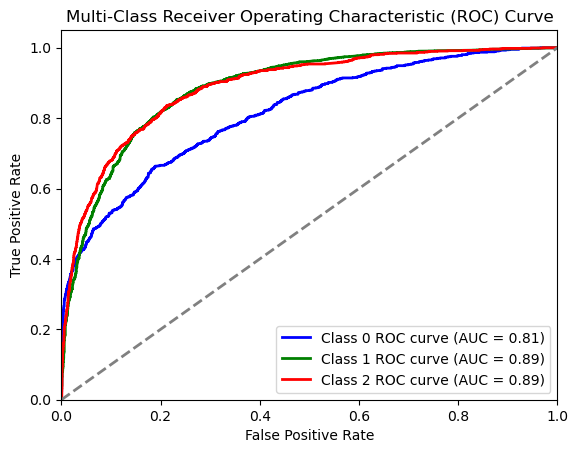

AUC for Class 0: 0.8147
AUC for Class 1: 0.8858
AUC for Class 2: 0.8885
Training Data Shape: (24000, 100)
Training Labels Shape: (24000,)
Confusion Matrix:
[[ 404  318  140]
 [ 169 3676  233]
 [ 113  297  650]]
Classification Report:
               precision    recall  f1-score   support

     Class 0       0.59      0.47      0.52       862
     Class 1       0.86      0.90      0.88      4078
     Class 2       0.64      0.61      0.62      1060

    accuracy                           0.79      6000
   macro avg       0.69      0.66      0.67      6000
weighted avg       0.78      0.79      0.78      6000

Test Accuracy = 0.7883


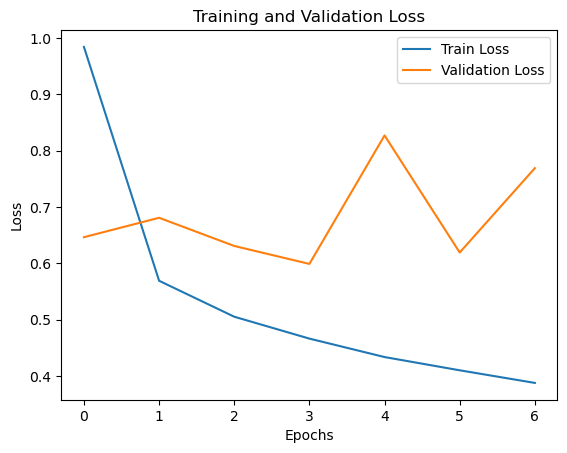

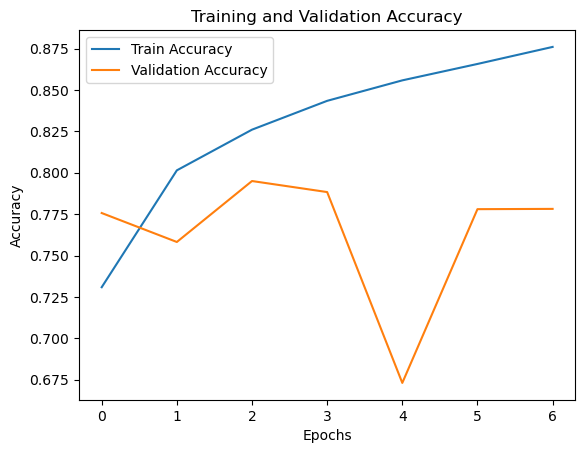

In [27]:

# Hyperparameters for the 3rd iteration
vocab_size = 10000 
embedding_dim = 100 
max_length = 100  

# Learning rate scheduler function
def lr_schedule(epoch):
    lr = 1e-3 * (0.8 ** epoch) 
    return lr

# Define the model with advanced regularization and optimization strategies
def create_model(units=128, dropout_rate=0.5, embedding_matrix=None, use_gru=False):
    model = Sequential()
    
    # If you have pre-trained embeddings, use them
    if embedding_matrix is not None:
        model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, 
                            input_length=max_length, weights=[embedding_matrix], trainable=False))
    else:
        model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
    
    # Experimenting with GRU or LSTM (if use_gru=True)
    if use_gru:
        model.add(Bidirectional(GRU(units=units, return_sequences=False, 
                                    kernel_regularizer=regularizers.l2(0.01)))) 
    else:
        model.add(Bidirectional(LSTM(units=units, return_sequences=False, 
                                      kernel_regularizer=regularizers.l2(0.01)))) 

    model.add(Dropout(dropout_rate))  
    model.add(BatchNormalization()) 
    model.add(Dense(3, activation='softmax', kernel_regularizer=regularizers.l2(0.01)))  

    # Optimizer choice (try AdamW or RMSProp)
    model.compile(optimizer=RMSprop(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

# Model training with hyperparameter tuning
start_time = time.time()

# Early stopping callback to halt training when validation loss stops improving
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Model Checkpoint to save the best model during training
model_checkpoint = ModelCheckpoint("best_model.h5", monitor="val_loss", save_best_only=True, verbose=1)

# Learning rate scheduler callback
lr_scheduler = LearningRateScheduler(lr_schedule)

# Create and train the model (try GRU for comparison)
model = create_model(units=128, dropout_rate=0.5, use_gru=True)

history = model.fit(X_train_pad, y_train_encoded, epochs=10, batch_size=32, 
                    validation_data=(X_test_pad, y_test_encoded),
                    callbacks=[early_stopping, model_checkpoint, lr_scheduler])

end_time = time.time()
train_time = end_time - start_time
print(f"Train Time = {train_time} seconds")

# Predicting with the trained model
y_pred_prob = model.predict(X_test_pad) 

# Convert the labels to binary format (one-vs-rest) for multi-class ROC curve
y_test_binary = label_binarize(y_test_encoded, classes=[0, 1, 2])

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):  # For each class (0, 1, 2)
    fpr[i], tpr[i], _ = roc_curve(y_test_binary[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure()
colors = ['blue', 'green', 'red']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} ROC curve (AUC = {roc_auc[i]:.2f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Labels and title
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# AUC Scores
for i in range(3):
    print(f"AUC for Class {i}: {roc_auc[i]:.4f}")

# Training data check
print(f"Training Data Shape: {X_train_pad.shape}")
print(f"Training Labels Shape: {y_train_encoded.shape}")

# Confusion Matrix
y_pred = np.argmax(y_pred_prob, axis=1)  # Convert probabilities to class labels
cm = confusion_matrix(y_test_encoded, y_pred)
print("Confusion Matrix:")
print(cm)

# F1 Score for Positive and Negative Classes
report = classification_report(y_test_encoded, y_pred, target_names=["Class 0", "Class 1", "Class 2"])
print("Classification Report:\n", report)

# Accuracy computation
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Test Accuracy = {accuracy:.4f}")

# Learning Curves - Plotting Training and Validation Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


# Iteration 4

Epoch 1/5
750/750 [==============================] - 161s 210ms/step - loss: 0.8497 - accuracy: 0.7387 - val_loss: 0.5959 - val_accuracy: 0.7855
Epoch 2/5
750/750 [==============================] - 171s 228ms/step - loss: 0.5130 - accuracy: 0.8198 - val_loss: 0.5840 - val_accuracy: 0.7972
Epoch 3/5
750/750 [==============================] - 182s 243ms/step - loss: 0.4264 - accuracy: 0.8532 - val_loss: 0.5632 - val_accuracy: 0.7935
Epoch 4/5
750/750 [==============================] - 469s 626ms/step - loss: 0.3748 - accuracy: 0.8756 - val_loss: 0.6240 - val_accuracy: 0.7905
Epoch 5/5
750/750 [==============================] - 205s 273ms/step - loss: 0.3401 - accuracy: 0.8880 - val_loss: 0.6226 - val_accuracy: 0.7965
Train Time = 1188.3740417957306 seconds
188/188 [==============================] - 21s 105ms/step


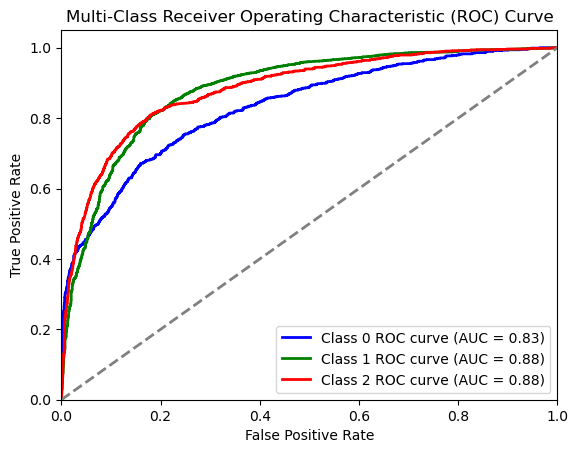

AUC for Class 0: 0.8313
AUC for Class 1: 0.8828
AUC for Class 2: 0.8827
Confusion Matrix:
[[ 337  364  161]
 [  61 3758  259]
 [  58  318  684]]
Classification Report:
               precision    recall  f1-score   support

     Class 0       0.74      0.39      0.51       862
     Class 1       0.85      0.92      0.88      4078
     Class 2       0.62      0.65      0.63      1060

    accuracy                           0.80      6000
   macro avg       0.73      0.65      0.68      6000
weighted avg       0.79      0.80      0.78      6000

Test_Accuracy = 0.7965
Training Time: 1188.3740 seconds


In [28]:


# Model configuration
vocab_size = 10000  
embedding_dim = 100 
max_length = 100  

# Define the model with more advanced hyperparameters and regularization
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
model.add(Bidirectional(LSTM(units=128, return_sequences=False, 
                              kernel_regularizer=regularizers.l2(0.01))))  
model.add(Dropout(0.5))  
model.add(Dense(3, activation='softmax'))  

# Compile the model with Adam optimizer
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training the model
start_time = time.time()
history = model.fit(X_train_pad, y_train_encoded, epochs=5, batch_size=32, validation_data=(X_test_pad, y_test_encoded))
end_time = time.time()
train_time = end_time - start_time
print(f"Train Time = {train_time} seconds")

# Predicting with the trained model
y_pred_prob = model.predict(X_test_pad)  # Get predicted probabilities

# Convert the labels to binary format (one-vs-rest) for multi-class ROC curve
y_test_binary = label_binarize(y_test_encoded, classes=[0, 1, 2])

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(3):  # For each class (0, 1, 2)
    fpr[i], tpr[i], _ = roc_curve(y_test_binary[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure()
colors = ['blue', 'green', 'red']
for i, color in zip(range(3), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} ROC curve (AUC = {roc_auc[i]:.2f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

# Labels and title
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# AUC Scores
for i in range(3):
    print(f"AUC for Class {i}: {roc_auc[i]:.4f}")

# Confusion Matrix
y_pred = np.argmax(y_pred_prob, axis=1)  
cm = confusion_matrix(y_test_encoded, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification Report
report = classification_report(y_test_encoded, y_pred, target_names=["Class 0", "Class 1", "Class 2"])
print("Classification Report:\n", report)

# Accuracy computation
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Test_Accuracy = {accuracy:.4f}")

# Training and Test time
print(f"Training Time: {train_time:.4f} seconds")


# Further steps to improve

1. **Use Pre-trained Models**: Leverage pre-trained models (e.g., BERT for text or ResNet for images) and fine-tune them on your specific task to improve performance, especially when you have limited training data.

2. **Ensemble Learning**: Combine predictions from different models (e.g., Random Forest, Gradient Boosting, etc.) to reduce bias and variance, improving overall model accuracy and robustness.

3. **Data Augmentation**: Use data augmentation techniques such as adding noise, cropping, or rotating for images, or back-translation and synonym replacement for text, to artificially expand the dataset. This can help the model generalize better and improve performance, especially when training data is scarce.

# Intepretability

In [29]:

# Access the first raw text instance
text_instance = X_test.iloc[0]  

# Initialize the LIME Text Explainer
explainer = LimeTextExplainer(class_names=["Class 0", "Class 1", "Class 2"])

# Define the prediction function for the model
def predict_fn(texts):
    # Convert the text data to padded sequences
    sequences = tokenizer.texts_to_sequences(texts)  
    padded_sequences = pad_sequences(sequences, maxlen=max_length)  
    return model.predict(padded_sequences)  

# Explain the instance using the LIME explainer
explanation = explainer.explain_instance(text_instance, predict_fn)

# Show the explanation in the notebook
explanation.show_in_notebook()


157/157 [==============================] - 15s 98ms/step


# Class Separability

188/188 [==============================] - 25s 132ms/step


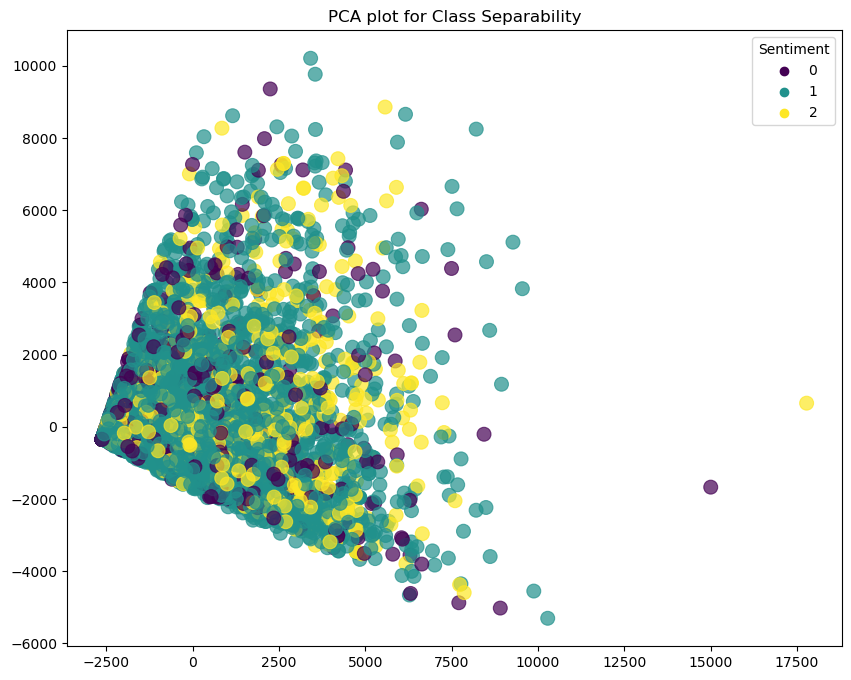

In [30]:
y_pred = model.predict(X_test_pad) 
y_pred_classes = np.argmax(y_pred, axis=1)  
y_true = y_test_encoded  

# 2. PCA Plot for Class Separability
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_pad) 

# Plotting PCA
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_true, palette="viridis", s=100, alpha=0.7, edgecolor=None)
plt.title('PCA plot for Class Separability')
plt.show()


# Cross Validation

Epoch 1/5
600/600 [==============================] - 108s 174ms/step - loss: 0.8827 - accuracy: 0.7316 - val_loss: 0.6107 - val_accuracy: 0.7792
Epoch 2/5
600/600 [==============================] - 118s 197ms/step - loss: 0.5182 - accuracy: 0.8188 - val_loss: 0.6033 - val_accuracy: 0.7925
Epoch 3/5
600/600 [==============================] - 97s 162ms/step - loss: 0.4778 - accuracy: 0.8374 - val_loss: 0.6454 - val_accuracy: 0.7900
Epoch 4/5
600/600 [==============================] - 95s 158ms/step - loss: 0.3674 - accuracy: 0.8789 - val_loss: 0.6331 - val_accuracy: 0.7769
Epoch 5/5
600/600 [==============================] - 97s 162ms/step - loss: 0.3233 - accuracy: 0.8955 - val_loss: 0.7025 - val_accuracy: 0.7773
Training Time for fold 1: 515.1996 seconds
150/150 [==============================] - 11s 66ms/step


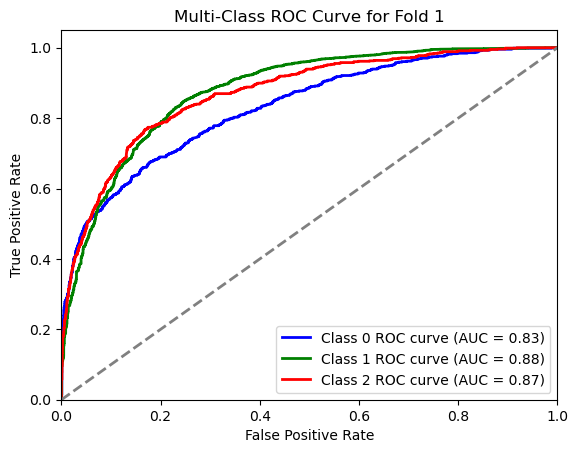

AUC for Class 0 in Fold 1: 0.8296
AUC for Class 1 in Fold 1: 0.8770
AUC for Class 2 in Fold 1: 0.8701
Confusion Matrix for Fold 1:
[[ 262  355   92]
 [  32 3139  115]
 [  54  348  403]]
Classification Report for Fold 1:
               precision    recall  f1-score   support

     Class 0       0.75      0.37      0.50       709
     Class 1       0.82      0.96      0.88      3286
     Class 2       0.66      0.50      0.57       805

    accuracy                           0.79      4800
   macro avg       0.74      0.61      0.65      4800
weighted avg       0.78      0.79      0.77      4800

Accuracy for Fold 1: 0.7925
Training Time for this fold: 515.1996 seconds
--------------------------------------------------
Epoch 1/5
600/600 [==============================] - 105s 169ms/step - loss: 0.8867 - accuracy: 0.7322 - val_loss: 0.6231 - val_accuracy: 0.7750
Epoch 2/5
600/600 [==============================] - 102s 170ms/step - loss: 0.5162 - accuracy: 0.8193 - val_loss: 0.6000 - val_

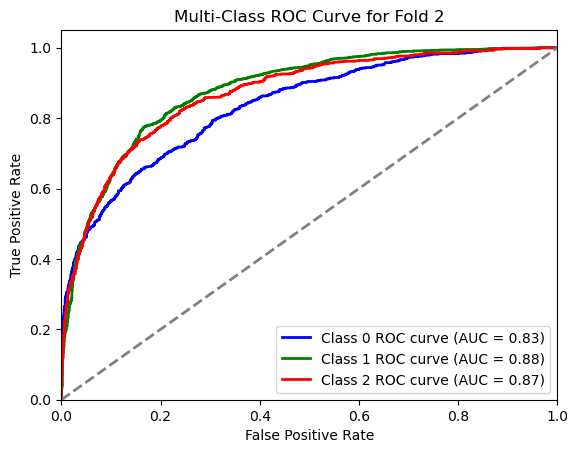

AUC for Class 0 in Fold 2: 0.8349
AUC for Class 1 in Fold 2: 0.8791
AUC for Class 2 in Fold 2: 0.8698
Confusion Matrix for Fold 2:
[[ 262  367   80]
 [  50 3120  116]
 [  34  394  377]]
Classification Report for Fold 2:
               precision    recall  f1-score   support

     Class 0       0.76      0.37      0.50       709
     Class 1       0.80      0.95      0.87      3286
     Class 2       0.66      0.47      0.55       805

    accuracy                           0.78      4800
   macro avg       0.74      0.60      0.64      4800
weighted avg       0.77      0.78      0.76      4800

Accuracy for Fold 2: 0.7831
Training Time for this fold: 513.0099 seconds
--------------------------------------------------
Epoch 1/5
600/600 [==============================] - 130s 209ms/step - loss: 0.8886 - accuracy: 0.7321 - val_loss: 0.6140 - val_accuracy: 0.7758
Epoch 2/5
600/600 [==============================] - 189s 315ms/step - loss: 0.5218 - accuracy: 0.8146 - val_loss: 0.5875 - val_

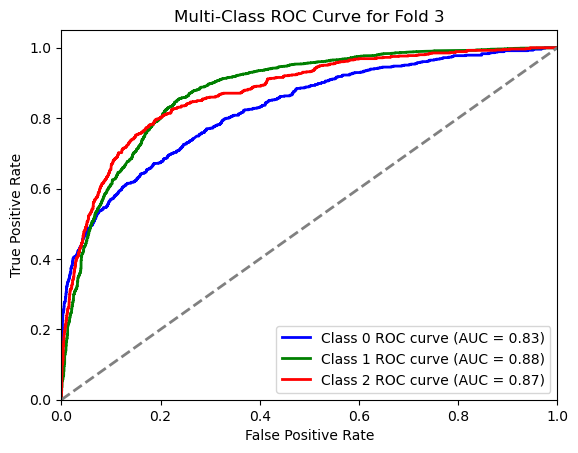

AUC for Class 0 in Fold 3: 0.8268
AUC for Class 1 in Fold 3: 0.8773
AUC for Class 2 in Fold 3: 0.8729
Confusion Matrix for Fold 3:
[[ 287  341   81]
 [  35 3118  133]
 [  71  339  395]]
Classification Report for Fold 3:
               precision    recall  f1-score   support

     Class 0       0.73      0.40      0.52       709
     Class 1       0.82      0.95      0.88      3286
     Class 2       0.65      0.49      0.56       805

    accuracy                           0.79      4800
   macro avg       0.73      0.61      0.65      4800
weighted avg       0.78      0.79      0.77      4800

Accuracy for Fold 3: 0.7917
Training Time for this fold: 869.0603 seconds
--------------------------------------------------
Epoch 1/5
600/600 [==============================] - 187s 305ms/step - loss: 0.8931 - accuracy: 0.7330 - val_loss: 0.6098 - val_accuracy: 0.7781
Epoch 2/5
600/600 [==============================] - 202s 337ms/step - loss: 0.5184 - accuracy: 0.8178 - val_loss: 0.5775 - val_

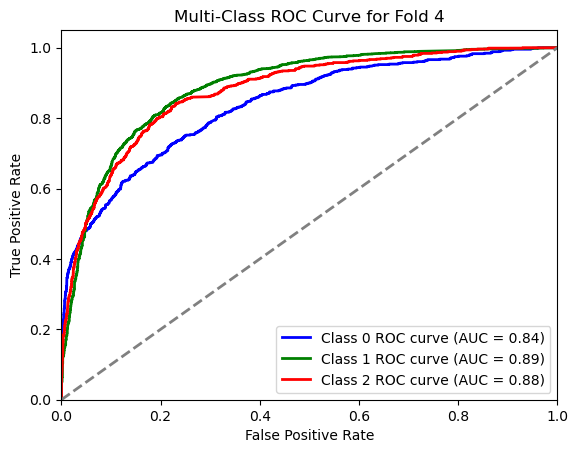

AUC for Class 0 in Fold 4: 0.8374
AUC for Class 1 in Fold 4: 0.8877
AUC for Class 2 in Fold 4: 0.8764
Confusion Matrix for Fold 4:
[[ 290  321   98]
 [  39 3103  144]
 [  58  321  426]]
Classification Report for Fold 4:
               precision    recall  f1-score   support

     Class 0       0.75      0.41      0.53       709
     Class 1       0.83      0.94      0.88      3286
     Class 2       0.64      0.53      0.58       805

    accuracy                           0.80      4800
   macro avg       0.74      0.63      0.66      4800
weighted avg       0.78      0.80      0.78      4800

Accuracy for Fold 4: 0.7956
Training Time for this fold: 1011.4970 seconds
--------------------------------------------------
Epoch 1/5
600/600 [==============================] - 509s 842ms/step - loss: 0.8835 - accuracy: 0.7335 - val_loss: 0.7022 - val_accuracy: 0.7556
Epoch 2/5
600/600 [==============================] - 210s 350ms/step - loss: 0.5301 - accuracy: 0.8123 - val_loss: 0.5804 - val

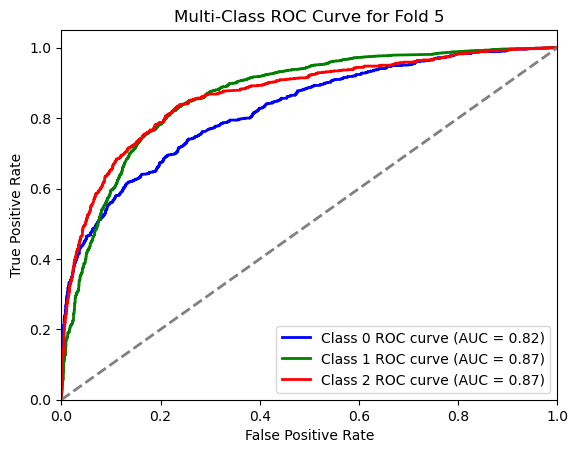

AUC for Class 0 in Fold 5: 0.8225
AUC for Class 1 in Fold 5: 0.8663
AUC for Class 2 in Fold 5: 0.8664
Confusion Matrix for Fold 5:
[[ 364  251   95]
 [ 189 2906  190]
 [ 102  232  471]]
Classification Report for Fold 5:
               precision    recall  f1-score   support

     Class 0       0.56      0.51      0.53       710
     Class 1       0.86      0.88      0.87      3285
     Class 2       0.62      0.59      0.60       805

    accuracy                           0.78      4800
   macro avg       0.68      0.66      0.67      4800
weighted avg       0.77      0.78      0.78      4800

Accuracy for Fold 5: 0.7794
Training Time for this fold: 1383.0651 seconds
--------------------------------------------------
Average Accuracy across all folds: 0.7884583333333334
Average AUC across all folds: 0.8596204649412721


In [31]:
# Model Configuration
vocab_size = 10000  # Vocabulary size
embedding_dim = 100  # Dimensionality of embedding
max_length = 100  # Maximum length of input sequences

# EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Cross-validation configuration
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists to store metrics
all_accuracies = []
all_auc_scores = []

# Example: Training on each fold
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_pad, y_train_encoded), 1):
    # Use .iloc[] for indexing the Series
    X_train_fold, X_val_fold = X_train_pad[train_idx], X_train_pad[val_idx]
    y_train_fold, y_val_fold = y_train_encoded.iloc[train_idx], y_train_encoded.iloc[val_idx]

    # Define the model
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
    model.add(Bidirectional(LSTM(units=128, return_sequences=False, 
                                  kernel_regularizer=regularizers.l2(0.01))))  
    model.add(Dropout(0.5))  
    model.add(Dense(3, activation='softmax'))  

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Train the model
    start_time = time.time()
    history = model.fit(X_train_fold, y_train_fold, epochs=5, batch_size=32, 
                        validation_data=(X_val_fold, y_val_fold), callbacks=[early_stopping])
    end_time = time.time()
    train_time = end_time - start_time
    print(f"Training Time for fold {fold}: {train_time:.4f} seconds")

    # Predicting with the trained model
    y_pred_prob = model.predict(X_val_fold)

    # One-vs-Rest Conversion for ROC Curve
    y_val_binary = label_binarize(y_val_fold, classes=[0, 1, 2])

    # Compute ROC curve and AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(3):  # For each class (0, 1, 2)
        fpr[i], tpr[i], _ = roc_curve(y_val_binary[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curves for each class
    plt.figure()
    colors = ['blue', 'green', 'red']
    for i, color in zip(range(3), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'Class {i} ROC curve (AUC = {roc_auc[i]:.2f})')

    # Plot diagonal line
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

    # Labels and title
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multi-Class ROC Curve for Fold {fold}')
    plt.legend(loc="lower right")
    plt.show()

    # AUC Scores
    for i in range(3):
        print(f"AUC for Class {i} in Fold {fold}: {roc_auc[i]:.4f}")

    # Confusion Matrix
    y_pred = np.argmax(y_pred_prob, axis=1)
    cm = confusion_matrix(y_val_fold, y_pred)
    print(f"Confusion Matrix for Fold {fold}:")
    print(cm)

    # Classification Report
    report = classification_report(y_val_fold, y_pred, target_names=["Class 0", "Class 1", "Class 2"])
    print(f"Classification Report for Fold {fold}:\n", report)

    # Accuracy computation
    accuracy = accuracy_score(y_val_fold, y_pred)
    print(f"Accuracy for Fold {fold}: {accuracy:.4f}")

    # Add accuracy and AUC to lists for further evaluation
    all_accuracies.append(accuracy)
    all_auc_scores.append(np.mean(list(roc_auc.values())))

    print(f"Training Time for this fold: {train_time:.4f} seconds")
    print("-" * 50)

# Print overall performance metrics after all folds
print("Average Accuracy across all folds:", np.mean(all_accuracies))
print("Average AUC across all folds:", np.mean(all_auc_scores))


# Conclusion

In conclusion, the model presented offers a solid foundation for multi-class classification using LSTM, dropout, and a softmax output layer. However, there are several avenues to explore for further improving its performance. Hyperparameter tuning, such as experimenting with different LSTM unit sizes, adjusting the learning rate, and modifying the dropout rate, could help optimize the model for better generalization. Additionally, incorporating pre-trained word embeddings, applying advanced regularization techniques like L2 regularization, and exploring model ensembling methods could help improve both accuracy and robustness. These adjustments would likely reduce overfitting, enhance model stability, and yield improved performance on unseen test data, leading to higher accuracy and AUC scores.